# Task 2 — Build Time Series Forecasting Models

Compare a classical **ARIMA** model against a **PyTorch LSTM** neural network for forecasting TSLA's closing price, using a chronological train/test split (train through 2024-12-31, test on 2025-01-01 onward).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

from src import data_loader, eda, arima_model, lstm_model, portfolio, backtest


In [2]:
raw = data_loader.fetch_asset_data(cache_dir='../data/raw')
cleaned = data_loader.clean_asset_data(raw)
prices = data_loader.combine_asset_data(cleaned, field='Adj Close')
tsla = prices['TSLA']
train, test = tsla[:'2024-12-31'], tsla['2025-01-01':]
print(f'Train: {len(train)} obs, Test: {len(test)} obs')

2026-07-04 07:45:58,588 [INFO] Loading cached data for TSLA from ../data/raw/TSLA.csv


2026-07-04 07:45:58,609 [INFO] Loading cached data for BND from ../data/raw/BND.csv


2026-07-04 07:45:58,626 [INFO] Loading cached data for SPY from ../data/raw/SPY.csv


2026-07-04 07:45:58,676 [INFO] TSLA: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:45:58,682 [INFO] BND: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:45:58,692 [INFO] SPY: reindexed to 2997 business days, filled 109 missing trading days


Train: 2608 obs, Test: 389 obs


## 2.1 ARIMA — automatic order selection

In [3]:
order, seasonal_order, auto_model = arima_model.find_best_order(train, seasonal=False)
print('Best order (p,d,q):', order)
arima_fitted = arima_model.fit_arima(train, order)
arima_fitted.summary()

Best order (p,d,q): (0, 1, 0)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   TSLA   No. Observations:                 2608
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8434.796
Date:                Sat, 04 Jul 2026   AIC                          16873.591
Time:                        07:45:59   BIC                          16885.323
Sample:                    01-02-2015   HQIC                         16877.841
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1493      0.121      1.239      0.215      -0.087       0.386
sigma2        37.8260      0.410     92.198      0.000      37.022      38.630
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):             13283.42
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):             475.33   Skew:                             0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

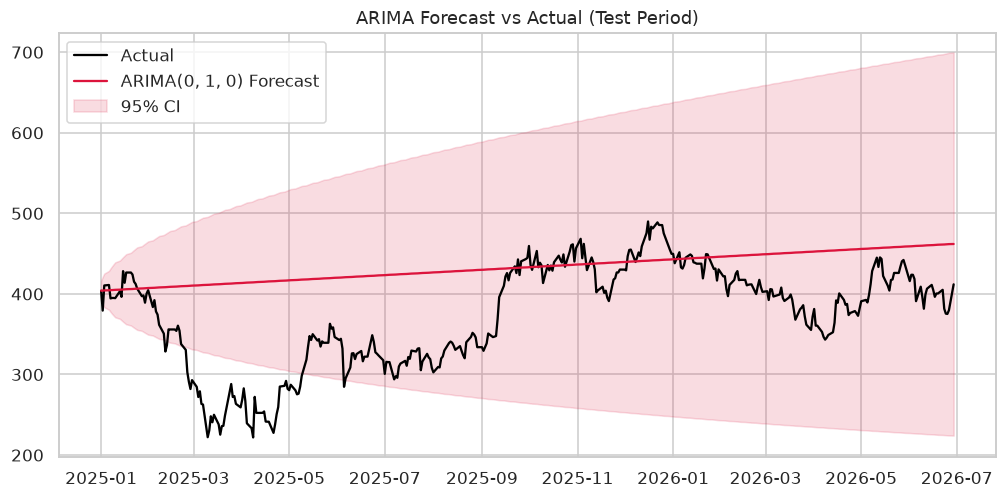

In [4]:
arima_fc, arima_lo, arima_hi = arima_model.forecast_arima(arima_fitted, steps=len(test))
arima_fc.index = arima_lo.index = arima_hi.index = test.index
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(test.index, test.values, label='Actual', color='black')
ax.plot(arima_fc.index, arima_fc.values, label=f'ARIMA{order} Forecast', color='crimson')
ax.fill_between(test.index, arima_lo, arima_hi, color='crimson', alpha=0.15, label='95% CI')
ax.legend(); ax.set_title('ARIMA Forecast vs Actual (Test Period)'); plt.show()

## 2.2 LSTM (PyTorch)

In [5]:
window = 60
train_vals = train.values.astype('float32')
test_vals = test.values.astype('float32')
lookback_vals = np.concatenate([train_vals[-window:], test_vals])
train_scaled, lookback_scaled, scaler = lstm_model.train_test_scale(train_vals, lookback_vals)
X_train, y_train = lstm_model.make_sequences(train_scaled, window=window)
X_test, y_test = lstm_model.make_sequences(lookback_scaled, window=window)
model = lstm_model.build_lstm_model(window=window, units=32, dropout=0.2)
history = lstm_model.fit(model, X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)
print('Final train loss:', history['loss'][-1], ' val loss:', history['val_loss'][-1])

Final train loss: 0.0017156222796378036  val loss: 0.003907923121005297


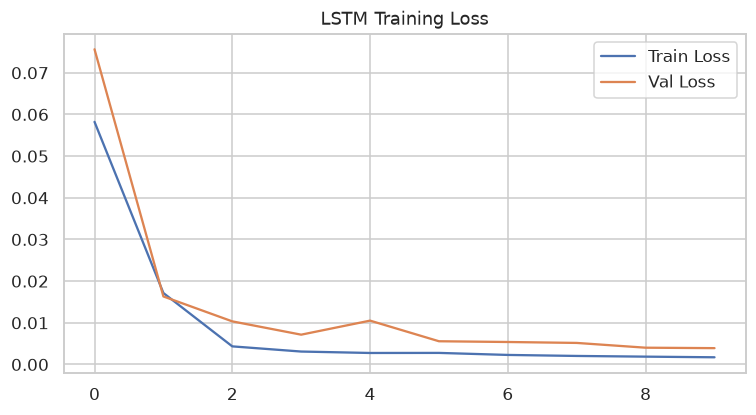

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(history['loss'], label='Train Loss'); ax.plot(history['val_loss'], label='Val Loss')
ax.legend(); ax.set_title('LSTM Training Loss'); plt.show()

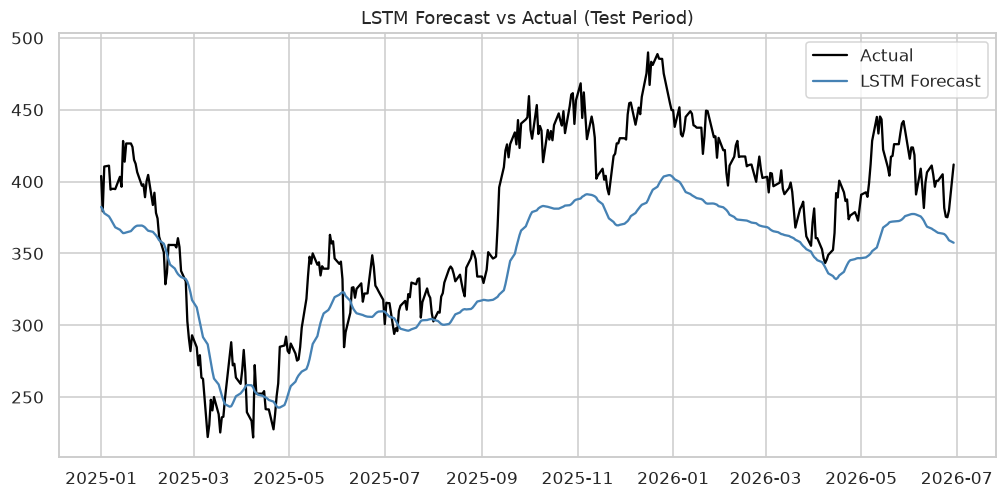

In [7]:
lstm_pred_scaled = lstm_model.predict(model, X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(test.index, test_vals, label='Actual', color='black')
ax.plot(test.index, lstm_pred, label='LSTM Forecast', color='steelblue')
ax.legend(); ax.set_title('LSTM Forecast vs Actual (Test Period)'); plt.show()

## 2.3 Model comparison: MAE, RMSE, MAPE

In [8]:
def metrics(pred, actual):
    pred, actual = np.asarray(pred), np.asarray(actual)
    mae = np.mean(np.abs(pred - actual))
    rmse = np.sqrt(np.mean((pred - actual)**2))
    mape = np.mean(np.abs((pred - actual)/actual)) * 100
    return mae, rmse, mape

arima_metrics = metrics(arima_fc.values, test.values)
lstm_metrics = metrics(lstm_pred, test_vals)
comparison = pd.DataFrame([
    {'model': f'ARIMA{order}', 'MAE': arima_metrics[0], 'RMSE': arima_metrics[1], 'MAPE_pct': arima_metrics[2]},
    {'model': 'LSTM', 'MAE': lstm_metrics[0], 'RMSE': lstm_metrics[1], 'MAPE_pct': lstm_metrics[2]},
]).set_index('model')
comparison.round(3)

,MAE,RMSE,MAPE_pct
model,,,
"ARIMA(0, 1, 0)",64.855,81.526,20.495
LSTM,37.047,43.126,9.529


### Conclusion

The model with the lower RMSE/MAE/MAPE is selected as the basis for the Task 3 future forecast and the Task 4 expected-return input for TSLA.